# 🦄 Unicorn Startups

#### *A unicorn startup is a privately held company valued at over **US$1 billion**.*

> **From Data to Discovery:** Uncovering the patterns behind the world's unicorn companies.

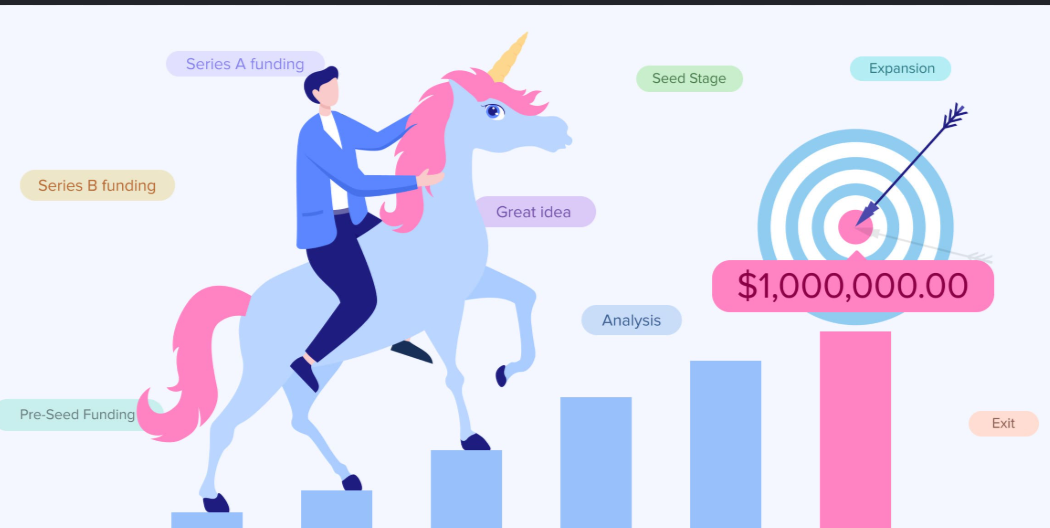

# 1. EDA
## Part 1 – Dataset Understanding

## Purpose of the Dataset
The dataset contains information about **unicorn companies** (privately held startups valued at over **US$1 billion**). It is designed to support **Exploratory Data Analysis (EDA)** by examining patterns in company valuation, funding, industries, geographic distribution, and investor participation.

## Unit of Observation
Each row represents **one unicorn company** and its associated characteristics, including its valuation, country, industry, funding amount, financial stage, and investor information.

## Dataset Size
- **Rows:** 1,500
- **Columns:** 11

In [1]:
import pandas as pd
#1. load the data set

df=pd.read_csv("unicorn_companies.csv")

In [2]:
#Inspect
df.head()

,Company,Valuation ($B),Date Joined,Country,City,Industry,Select Investors,Founded Year,Total Raised ($B),Financial Stage,Investors Count
0,Grid Group94,1.58,2026-12-04,United States,Los Angeles,Data management & analytics,"DST Global, Kleiner Perkins Caufield & Byers, ...",2016,0.305,Series E,5
1,Meta Labs,2.55,2026-11-26,Germany,Munich,Fintech,Y Combinator,2022,0.528,Series D,12
2,Link Group,2.32,2026-10-14,Israel,Tel Aviv,Health,"New Enterprise Associates, DST Global, Alibaba...",2015,0.940,Series C,16
3,Aeroify68,4.26,2026-10-14,United States,New York,Fintech,"DST Global, Thrive Capital",2022,1.938,Series C,2
4,Finly38,7.38,2026-09-26,United States,Los Angeles,Other,"SoftBank Group, Sequoia Capital",2020,1.242,Series F,11


In [3]:
# shape of the data set 
print(df.shape)
# name of columns
print(df.columns)

(1500, 11)
Index(['Company', 'Valuation ($B)', 'Date Joined', 'Country', 'City',
       'Industry', 'Select Investors', 'Founded Year', 'Total Raised ($B)',
       'Financial Stage', 'Investors Count'],
      dtype='object')


## Feature Types

In [4]:
#Numercial vs catgorical data
numerical_columns=df.select_dtypes(include='number').columns
categorical_column=df.select_dtypes(exclude='number').columns

print(numerical_columns,len(numerical_columns))
print(categorical_column,len(categorical_column))


Index(['Valuation ($B)', 'Founded Year', 'Total Raised ($B)',
       'Investors Count'],
      dtype='object') 4
Index(['Company', 'Date Joined', 'Country', 'City', 'Industry',
       'Select Investors', 'Financial Stage'],
      dtype='object') 7


### Numerical Features
- Valuation ($B) :The estimated market value of the company.
- Founded Year
- Total Raised ($B) : Total Raised is the total amount of money raised from all investors combined across all funding rounds.
- Investors Count

### Categorical Features
- Company: name of the company
- Date Joined: the date the company joined the unicorn club
- Country
- City
- Industry
- Select Investors: investors names comma seprating if we have more than one investor
- Financial Stage

## Target Variable
This dataset does **not** have a predefined target variable because it is primarily intended for exploratory data analysis. However, if this dataset were used for a predictive machine learning task, **Investors Count** could be selected as a target variable to predict the number of investors based on the other company characteristics.

## Part 2 – Initial Exploration
### Perform an initial inspection of the dataset using appropriate Pandas functions.
### Your exploration should include:
- Dataset shape
- Column names
- Data types
- Summary statistics
- First few records

In [5]:
#shape
print(df.shape)
#columns name
print(df.columns)
# data types
print(df.dtypes)

(1500, 11)
Index(['Company', 'Valuation ($B)', 'Date Joined', 'Country', 'City',
       'Industry', 'Select Investors', 'Founded Year', 'Total Raised ($B)',
       'Financial Stage', 'Investors Count'],
      dtype='object')
Company               object
Valuation ($B)       float64
Date Joined           object
Country               object
City                  object
Industry              object
Select Investors      object
Founded Year           int64
Total Raised ($B)    float64
Financial Stage       object
Investors Count        int64
dtype: object


In [6]:
# Summary statistics
print(df.describe())

       Valuation ($B)  Founded Year  Total Raised ($B)  Investors Count
count     1500.000000   1500.000000        1500.000000      1500.000000
mean         5.658787   2011.442667           1.707883        10.122667
std         12.665775      5.683448           4.371883         4.775090
min          1.000000   1995.000000           0.111000         1.000000
25%          1.680000   2008.000000           0.431000         6.000000
50%          2.370000   2012.000000           0.705000        10.000000
75%          4.505000   2016.000000           1.243250        14.000000
max        149.030000   2023.000000          60.653000        19.000000


In [7]:
# first few rows
df.head()

,Company,Valuation ($B),Date Joined,Country,City,Industry,Select Investors,Founded Year,Total Raised ($B),Financial Stage,Investors Count
0,Grid Group94,1.58,2026-12-04,United States,Los Angeles,Data management & analytics,"DST Global, Kleiner Perkins Caufield & Byers, ...",2016,0.305,Series E,5
1,Meta Labs,2.55,2026-11-26,Germany,Munich,Fintech,Y Combinator,2022,0.528,Series D,12
2,Link Group,2.32,2026-10-14,Israel,Tel Aviv,Health,"New Enterprise Associates, DST Global, Alibaba...",2015,0.940,Series C,16
3,Aeroify68,4.26,2026-10-14,United States,New York,Fintech,"DST Global, Thrive Capital",2022,1.938,Series C,2
4,Finly38,7.38,2026-09-26,United States,Los Angeles,Other,"SoftBank Group, Sequoia Capital",2020,1.242,Series F,11


### After exploring the data, answer:
#### What did you notice immediately?
- Unicorn valuations vary widely, ranging from US$1 billion to US$149.03 billion, suggesting the presence of very high-value companies.
- Most startups unicorn founded after 2008 as 25% of the data values lie below this number, and 75% lie above it.
- The average unicorn valuation (US$5.66B) is much higher than the median (US$2.37B), indicating the distribution is likely right-skewed.
- The number of investors ranges from 1 to 19, with an average of about 10 investors per company.

#### Are there any obvious problems?
- Date Joined is stored as an object instead of a datetime type and should be converted for time-based analysis.
- Numerical variables, particularly Valuation ($B) and Total Raised ($B), appear to contain potential outliers because their maximum values are much larger than the upper quartiles
- Select Investors contains multiple investor names in a single cell, making it more difficult to analyse without preprocessing.
#### Which columns require further investigation?
- Founded Year: By examining company age and time taken to become a unicorn.
- Industry and Country: Explore the distribution of unicorn companies across industries and countries.
- Valuation ($B): Check its distribution and identify potential outliers.
- Total Raised ($B) (is the total funding that the company has received from investors): Investigate its relationship with valuation and look for extreme funding amounts.

## Part 3 – Data Quality Assessment
### Investigate the dataset for the following problems.
1. Missing Values



In [8]:
print(df.isna().sum())
print("\nNo Missing Data")


Company              0
Valuation ($B)       0
Date Joined          0
Country              0
City                 0
Industry             0
Select Investors     0
Founded Year         0
Total Raised ($B)    0
Financial Stage      0
Investors Count      0
dtype: int64

No Missing Data


### 2. Duplicate Rows

In [9]:
print(df.duplicated().sum())
print("No duplicated Rows")

0
No duplicated Rows


### 3. Wrong Data Types

- Are any columns stored using incorrect data types?
- How did you identify them?
- How did you correct them?


In [10]:
# Date Joined
df["Date Joined"].dtypes

dtype('O')

- The date joined should be converted to date object instead of string so it can be used in analysis
- I identify while inspecting the data types earlier
- Correcting it by converting to date time object

In [11]:
df_analysis=df.copy()
df_analysis["Date Joined"]=pd.to_datetime(df_analysis["Date Joined"])
print(df_analysis.dtypes)

Company                      object
Valuation ($B)              float64
Date Joined          datetime64[ns]
Country                      object
City                         object
Industry                     object
Select Investors             object
Founded Year                  int64
Total Raised ($B)           float64
Financial Stage              object
Investors Count               int64
dtype: object


In [12]:
df_analysis["Date Joined"]

0      2026-12-04
1      2026-11-26
2      2026-10-14
3      2026-10-14
4      2026-09-26
          ...    
1495   2004-06-18
1496   2004-03-28
1497   2004-02-29
1498   2003-06-13
1499   2001-02-16
Name: Date Joined, Length: 1500, dtype: datetime64[ns]

In [13]:
# Year the company became a unicorn, this can be used with founded year coparsions
df_analysis['Joined Year'] = df_analysis['Date Joined'].dt.year


#### 4. Invalid Values
- Identify values that are logically incorrect.
- Examples include:
   - Impossible invalid values

- For each issue:
    - Explain how you detected it.
    - Explain how you treated it.


In [14]:
#Detect invalid if for example prices are in negtive 
numerical_columns=df_analysis.select_dtypes(include='number').columns
for col in numerical_columns:
    print(df_analysis[col].describe())


print("I don't see any values that are outside reasonable ranges for each numerical column.")

count    1500.000000
mean        5.658787
std        12.665775
min         1.000000
25%         1.680000
50%         2.370000
75%         4.505000
max       149.030000
Name: Valuation ($B), dtype: float64
count    1500.000000
mean     2011.442667
std         5.683448
min      1995.000000
25%      2008.000000
50%      2012.000000
75%      2016.000000
max      2023.000000
Name: Founded Year, dtype: float64
count    1500.000000
mean        1.707883
std         4.371883
min         0.111000
25%         0.431000
50%         0.705000
75%         1.243250
max        60.653000
Name: Total Raised ($B), dtype: float64
count    1500.000000
mean       10.122667
std         4.775090
min         1.000000
25%         6.000000
50%        10.000000
75%        14.000000
max        19.000000
Name: Investors Count, dtype: float64
count    1500.000000
mean     2018.916667
std         4.858545
min      2001.000000
25%      2016.000000
50%      2020.000000
75%      2023.000000
max      2026.000000
Name: Join

### 5.Inconsistent Categories
- Check whether categorical values are written consistently.



In [15]:
categorical_column=df_analysis.select_dtypes(exclude=['number', 'datetime']).columns
categorical_column

Index(['Company', 'Country', 'City', 'Industry', 'Select Investors',
       'Financial Stage'],
      dtype='object')

In [16]:
# detect each column unique values in categorical columns if theres(miss-spell meaning the same thing)
for col in categorical_column:
    print(f"\n{col}:")
    print(df[col].unique())



Company:
['Grid Group94' 'Meta Labs' 'Link Group' ... 'Nova Networks97'
 'Nex Networks60' 'AutoGrid']

Country:
['United States' 'Germany' 'Israel' 'China' 'Singapore' 'Canada'
 'South Korea' 'France' 'India' 'Brazil' 'Indonesia' 'Australia'
 'United Kingdom' 'Japan' 'Sweden']

City:
['Los Angeles' 'Munich' 'Tel Aviv' 'New York' 'Austin' 'Shenzhen'
 'Singapore' 'Toronto' 'Palo Alto' 'Seattle' 'Seoul' 'San Francisco'
 'Boston' 'Paris' 'Chicago' 'Gurugram' 'Sao Paulo' 'Beijing' 'Curitiba'
 'Mumbai' 'Jakarta' 'Berlin' 'Bengaluru' 'Melbourne' 'Shanghai'
 'Cambridge' 'Hangzhou' 'Pune' 'Guangzhou' 'Tokyo' 'Stockholm' 'London'
 'Jerusalem' 'New Delhi' 'Vancouver' 'Montreal' 'Oxford' 'Sydney']

Industry:
['Data management & analytics' 'Fintech' 'Health' 'Other'
 'Artificial intelligence' 'Internet software & services' 'Edtech'
 'Supply chain, logistics, & delivery' 'Travel' 'Consumer & retail'
 'Cybersecurity' 'Auto & transportation' 'Hardware'
 'E-commerce & direct-to-consumer']

Select Inve

### All categorical values are written consistently.

#### 6. Outliers
### Detect outliers using appropriate techniques (such as Box Plot and IQR).
- For your analysis:
  - How many outliers were found?
  - Are they real observations or possible errors?
  - Did you keep, remove, or cap them?
  - Justify your decision.


In [17]:
# Using IQR
def detect_iqr_outliers(
    data: pd.DataFrame,
    column: str,
) -> dict:
    # TODO
    #get the column and remove missing values
    series=data[column].dropna()
    q1, q2, q3 =series.quantile([0.25, 0.5, 0.75])
    IQR=q3-q1
    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR

    #create a mask to filter
    mask = (data[column] < lower_bound) | (data[column] > upper_bound)
    outlier_rows = data[mask]
    outliers_count = len(outlier_rows)



    return {
        "Upper_Bound":upper_bound,
        "Lower_Bound":lower_bound,
        "Outliers_Count":outliers_count,
        "Outliers_Rows":outlier_rows
    }

    

In [18]:
# Build an outlier summery
summary = []

for col in numerical_columns:

    result = detect_iqr_outliers(df_analysis, col)

    summary.append({
        "Column": col,
        "Lower_Bound": result["Lower_Bound"],
        "Upper_Bound": result["Upper_Bound"],
        "Outliers_Count": result["Outliers_Count"],
    })

# Build the summary table
summary_df = pd.DataFrame(summary)

summary_df

,Column,Lower_Bound,Upper_Bound,Outliers_Count
0,Valuation ($B),-2.557500,8.742500,195
1,Founded Year,1996.000000,2028.000000,1
2,Total Raised ($B),-0.787375,2.461625,217
3,Investors Count,-6.000000,26.000000,0
4,Joined Year,2005.500000,2033.500000,9


### Finding in outliers detection
- Outliers were detected in Valuation ($B), these values were retained because they represent legitimate high-value unicorn companies rather than data errors. (Keep)
- Founded Year: min value is 1995 and the lower bound is 1996, hence its not a data error its a valid year in the dataset (Keep)
- Some unicorns raise exceptionally large amounts of funding. These are likely valid observations. (Keep)
- Joined Year: the year the company became a unicorn, the lower bound is 2005, whilst min 2001, and max is 2026, hence the values before 2005 were considered statisically outliers while its valid year these 9 rows need be indpected to be actually below 2005 and not error data (inspect)






In [19]:
# inspect joined year 9 rows
joined_year_inspection = detect_iqr_outliers(df_analysis, "Joined Year")

joined_year_outliers = joined_year_inspection["Outliers_Rows"]
print(joined_year_outliers)

                    Company  Valuation ($B) Date Joined        Country  \
1491                 Nexio4            1.99  2005-11-19  United States   
1492              Link Labs            2.10  2005-09-13  United States   
1493           OmniVertex69            2.37  2004-12-22  United States   
1494               FinLink1            1.08  2004-10-20          India   
1495  Zenith Technologies68            1.06  2004-06-18  United States   
1496      Shift Solutions64            2.16  2004-03-28          India   
1497        Nova Networks97           16.24  2004-02-29          India   
1498         Nex Networks60            4.02  2003-06-13  United States   
1499               AutoGrid            1.09  2001-02-16  United States   

               City                         Industry  \
1491       New York                           Health   
1492  San Francisco                          Fintech   
1493         Austin  E-commerce & direct-to-consumer   
1494      New Delhi     Internet so

### Indeed all nine values were valid years its only because its below 2005.5 lower bound hence were keeping these values as well
- 2005,2004,2004,2004,2004,2004,2003,2001  

### 7. Class Imbalance (If Applicable)
- Not applicable since my target varible is a continous number

## Part 4 – Exploratory Data Analysis
Perform a meaningful exploration of the cleaned dataset.
Include:
Numerical Analysis
Examples:
Mean
Median
Standard deviation
Distribution


In [20]:
#The numerical data already clean with oultliers kept as they are meaningful
df_analysis.describe()

,Valuation ($B),Date Joined,Founded Year,Total Raised ($B),Investors Count,Joined Year
count,1500.000000,1500,1500.000000,1500.000000,1500.000000,1500.000000
mean,5.658787,2019-05-30 17:30:14.400000,2011.442667,1.707883,10.122667,2018.916667
min,1.000000,2001-02-16 00:00:00,1995.000000,0.111000,1.000000,2001.000000
25%,1.680000,2016-01-28 18:00:00,2008.000000,0.431000,6.000000,2016.000000
50%,2.370000,2020-04-11 00:00:00,2012.000000,0.705000,10.000000,2020.000000
75%,4.505000,2023-05-30 12:00:00,2016.000000,1.243250,14.000000,2023.000000
max,149.030000,2026-12-04 00:00:00,2023.000000,60.653000,19.000000,2026.000000
std,12.665775,NaN,5.683448,4.371883,4.775090,4.858545


#### Categorical Analysis
Examples:
Frequency tables
Percentages
Category comparisons


#### Before checking frequncies i will fix the column select investros into unique values instead of lists
- The Select Investors column will be preprocessed by splitting the comma-separated investor lists into individual investor names for frequency analysis.

In [21]:
df_analysis["Select Investors"].unique()

array(['DST Global, Kleiner Perkins Caufield & Byers, Y Combinator, Bessemer Venture Partners',
       'Y Combinator',
       'New Enterprise Associates, DST Global, Alibaba Group, Founders Fund',
       ..., 'Greylock Partners, Accel, Alibaba Group',
       'Insight Partners, Tiger Global Management, Google Ventures',
       'Thrive Capital, General Atlantic, New Enterprise Associates, Bessemer Venture Partners'],
      dtype=object)

In [22]:
#Pre process investors + create freq table
all_investors = (
    df_analysis["Select Investors"]
    .str.split(", ")
    .explode()
)

investor_freq = all_investors.value_counts().to_frame("Frequency")

investor_freq["Percentage (%)"] = (
    investor_freq["Frequency"] / len(df_analysis) * 100
).round(2)

investor_freq

,Frequency,Percentage (%)
Select Investors,,
Tiger Global Management,195,13.00
Thrive Capital,193,12.87
Khosla Ventures,193,12.87
DST Global,179,11.93
Benchmark,177,11.80
Google Ventures,177,11.80
Coatue Management,175,11.67
Tencent Holdings,174,11.60
Alibaba Group,171,11.40


- So rn we can inspect the investors distirbtuon for example Tiger Global Management has the highest number of unicorns they invested in

In [23]:
print(df_analysis["Company"].value_counts())
print("Company is an identifier, so a frequency analysis isn't very meaningful since each company appears once")


Company
Grid Group94    1
HealthStream    1
MetaWave        1
Space Group     1
Zenith Hub36    1
               ..
Omni Labs91     1
Data Group50    1
Smart Base70    1
Cloudly69       1
AutoGrid        1
Name: count, Length: 1500, dtype: int64
Company is an identifier, so a frequency analysis isn't very meaningful since each company appears once


### Frequency Table for each catagory

In [24]:

categorical_columns=["Country","City","Industry","Financial Stage"]
for col in categorical_columns:
    table = (
        df_analysis[col]
        .value_counts()
        .to_frame("Frequency")
    )

    table["Percentage (%)"] = (
        table["Frequency"] / len(df_analysis) * 100
    ).round(2)

    print(f"\n{col}")
    display(table)


Country


,Frequency,Percentage (%)
Country,,
United States,709,47.27
China,213,14.20
India,118,7.87
United Kingdom,100,6.67
Germany,57,3.80
Brazil,53,3.53
Canada,39,2.60
Israel,34,2.27
France,33,2.20



City


,Frequency,Percentage (%)
City,,
Seattle,103,6.87
Palo Alto,96,6.40
San Francisco,95,6.33
Chicago,93,6.20
New York,89,5.93
Austin,84,5.60
Los Angeles,76,5.07
Boston,73,4.87
Hangzhou,49,3.27



Industry


,Frequency,Percentage (%)
Industry,,
Fintech,293,19.53
Internet software & services,282,18.80
E-commerce & direct-to-consumer,169,11.27
Artificial intelligence,156,10.40
Health,133,8.87
Data management & analytics,82,5.47
Cybersecurity,80,5.33
Other,74,4.93
"Supply chain, logistics, & delivery",59,3.93



Financial Stage


,Frequency,Percentage (%)
Financial Stage,,
Series D,466,31.07
Series C,310,20.67
Series E,294,19.60
Series F,141,9.40
Pre-IPO,139,9.27
Private Equity,77,5.13
Series B,73,4.87


### Relationship Analysis
- Investigate relationships between variables.

1. Correlation matrix



In [25]:
import numpy as np
# Correlation matrix
correlation = df_analysis[
    ["Valuation ($B)", "Total Raised ($B)",
     "Founded Year", "Joined Year", "Investors Count"]
].corr()

# Keep only the upper triangle so we remove duplicates and diagonal
upper = correlation.where(
    np.triu(np.ones(correlation.shape), k=1).astype(bool)
)

# strongest corr
strongest = (
    upper.stack()
         .rename("Correlation")
         .reindex(upper.stack().abs().sort_values(ascending=False).index)
         .to_frame()
)

strongest

Correlation
Valuation ($B)    Total Raised ($B)     0.931036
Founded Year      Joined Year           0.864081
Valuation ($B)    Investors Count       0.015549
                  Founded Year          0.012878
Total Raised ($B) Founded Year          0.011215
                  Investors Count       0.007281
Founded Year      Investors Count       0.005913
Total Raised ($B) Joined Year           0.004518
Valuation ($B)    Joined Year           0.004225
Joined Year       Investors Count       0.001045

### Correlation Analysis

- The strongest positive relationship was observed between Valuation ($B) and Total Raised ($B) (r = 0.931), indicating that companies that raise more funding generally tend to have higher valuations.

- A strong positive correlation was also found between Founded Year and Joined Year (r = 0.864), suggesting that newer companies tend to become unicorns in more recent years.

- All remaining correlations were very close to zero, indicating little to no linear relationship between those variable pairs.

- Investors Count showed almost no correlation with valuation, funding, or company age, implying that having more investors does not necessarily correspond to higher valuations or larger funding amounts in this dataset.

2. Scatter plots


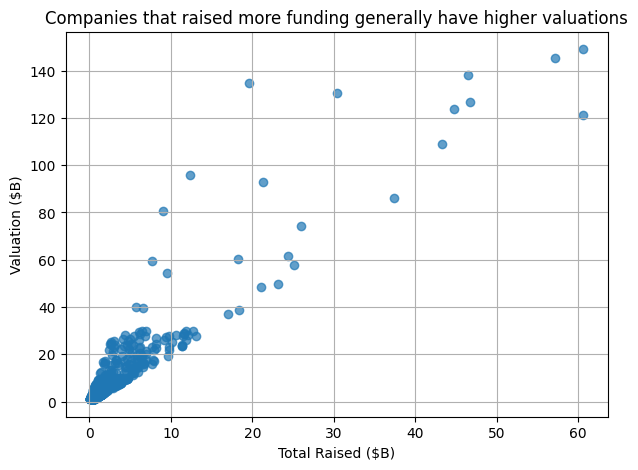

The points show a clear upward trend, confirming the strong positive correlation


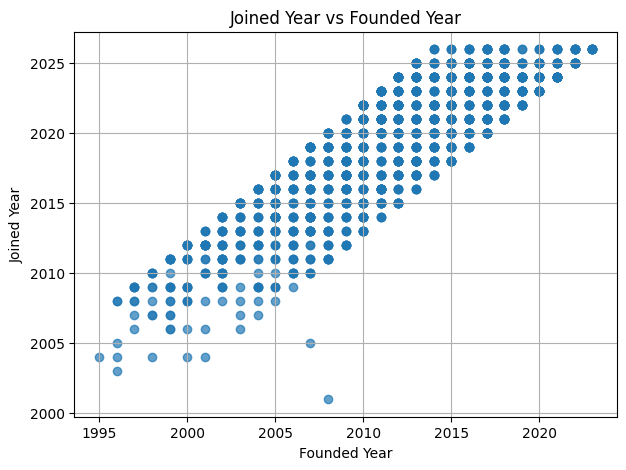

In [26]:
import matplotlib.pyplot as plt

# Total Raised vs Valuation
plt.figure(figsize=(7, 5))
plt.scatter(
    df_analysis["Total Raised ($B)"],
    df_analysis["Valuation ($B)"],
    alpha=0.7
)
plt.title("Companies that raised more funding generally have higher valuations")
plt.xlabel("Total Raised ($B)")
plt.ylabel("Valuation ($B)")
plt.grid(True)
plt.show()
print("The points show a clear upward trend, confirming the strong positive correlation")

# Founded Year vs Joined Year
plt.figure(figsize=(7, 5))
plt.scatter(
    df_analysis["Founded Year"],
    df_analysis["Joined Year"],
    alpha=0.7
)
plt.title("Joined Year vs Founded Year")
plt.xlabel("Founded Year")
plt.ylabel("Joined Year")
plt.grid(True)
plt.show()

- some years seems off like a company founded in 2007 became unicorn before 2005?
- lets check that

In [27]:
df_analysis[df_analysis["Joined Year"] < df_analysis["Founded Year"]]

,Company,Valuation ($B),Date Joined,Country,City,Industry,Select Investors,Founded Year,Total Raised ($B),Financial Stage,Investors Count,Joined Year
1491,Nexio4,1.99,2005-11-19,United States,New York,Health,"Tiger Global Management, SoftBank Group, Googl...",2007,0.840,Series B,15,2005
1499,AutoGrid,1.09,2001-02-16,United States,Austin,Fintech,"Thrive Capital, General Atlantic, New Enterpri...",2008,0.326,Private Equity,5,2001


In [28]:
# since only 2 records seem invalid, i will srop these records
df_analysis = df_analysis[
    df_analysis["Joined Year"] >= df_analysis["Founded Year"]
]


In [29]:
(df_analysis["Joined Year"] < df_analysis["Founded Year"]).sum()

0

- Logical consistency checks identified two records where the unicorn joining year occurred before the company was founded. Since these records represented impossible values and accounted for only 2 out of 1,500 observations, they were removed

### lets re-plot the years graph

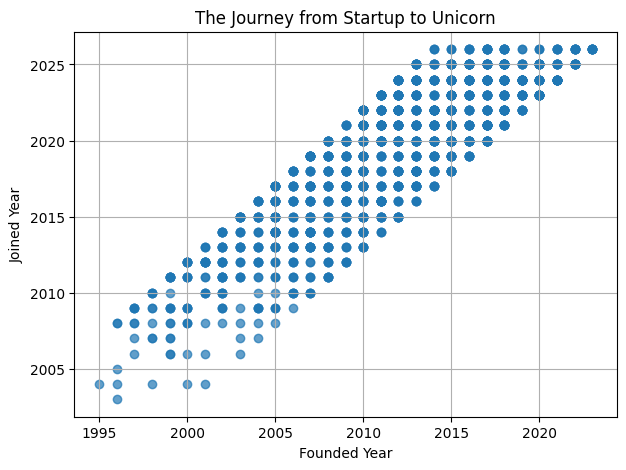

In [30]:
# Founded Year vs Joined Year
plt.figure(figsize=(7, 5))
plt.scatter(
    df_analysis["Founded Year"],
    df_analysis["Joined Year"],
    alpha=0.7
)
plt.title("The Journey from Startup to Unicorn")
plt.xlabel("Founded Year")
plt.ylabel("Joined Year")
plt.grid(True)
plt.show()

3. Grouped Summaries

In [31]:
df_analysis.groupby("Industry")["Valuation ($B)"].mean().sort_values(ascending=False)

Industry
Supply chain, logistics, & delivery    9.997966
Cybersecurity                          6.935125
Data management & analytics            6.215488
Health                                 6.118864
E-commerce & direct-to-consumer        5.839822
Fintech                                5.836370
Internet software & services           5.368688
Hardware                               5.323830
Artificial intelligence                4.784295
Edtech                                 4.453125
Consumer & retail                      4.398077
Other                                  4.265405
Auto & transportation                  4.090370
Travel                                 2.153077
Name: Valuation ($B), dtype: float64

4. Pivot Tables
 - Which industries have the highest average valuation within each country?

In [32]:
pd.pivot_table(
    df_analysis,
    values="Valuation ($B)",
    index="Country",
    columns="Industry",
    aggfunc="mean"
).round(2)

Industry,Artificial intelligence,Auto & transportation,Consumer & retail,Cybersecurity,Data management & analytics,E-commerce & direct-to-consumer,Edtech,Fintech,Hardware,Health,Internet software & services,Other,"Supply chain, logistics, & delivery",Travel
Country,,,,,,,,,,,,,,
Australia,1.97,1.02,NaN,2.99,1.85,1.59,NaN,2.44,NaN,26.07,2.00,1.52,NaN,NaN
Brazil,2.19,2.85,1.09,1.63,1.46,4.98,1.53,5.86,8.34,4.93,5.34,1.39,2.23,2.95
Canada,2.59,3.51,NaN,2.58,15.95,14.84,NaN,3.19,2.52,17.75,5.06,2.77,48.32,2.35
China,2.70,3.74,1.28,12.14,3.51,5.61,8.77,6.25,8.28,3.66,2.99,2.34,4.17,2.55
France,13.82,17.16,5.88,1.94,NaN,2.38,NaN,4.83,NaN,2.12,2.96,2.93,2.63,1.90
Germany,6.54,2.42,NaN,3.74,2.51,5.54,2.10,4.12,NaN,8.19,3.12,1.58,7.56,NaN
India,3.69,2.64,12.76,5.57,3.72,3.96,2.47,12.48,1.87,10.81,5.11,2.34,7.44,NaN
Indonesia,1.45,2.60,NaN,2.43,6.57,3.94,NaN,5.86,NaN,2.64,3.06,25.29,75.64,NaN
Israel,1.90,NaN,NaN,1.32,1.72,3.33,NaN,3.15,4.89,2.08,2.43,5.36,1.56,1.54


- Canada stands out in the Supply chain, logistics, & delivery industry, with the highest value (48.32) among most country–industry combinations

### Part 5 – Data Visualization


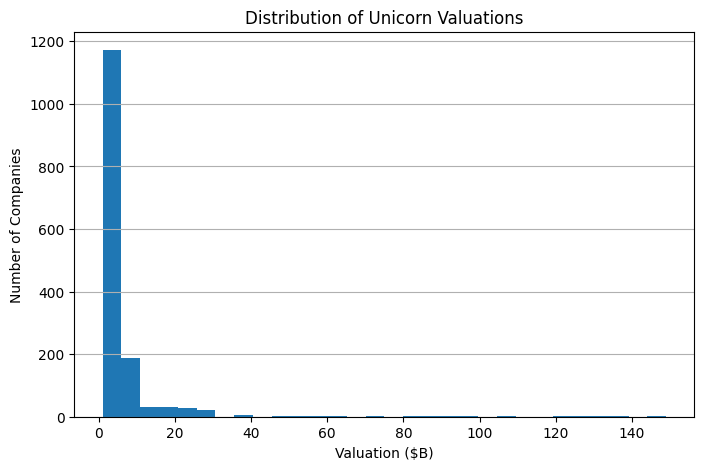

In [33]:
#Distribution of Unicorn Valuations
plt.figure(figsize=(8,5))
plt.hist(df_analysis["Valuation ($B)"], bins=30)
plt.title("Distribution of Unicorn Valuations")
plt.xlabel("Valuation ($B)")
plt.ylabel("Number of Companies")
plt.grid(axis="y")
plt.show()

- Most unicorn companies have a valuation close to US$1 billion, while only a few companies reach much higher valuations.

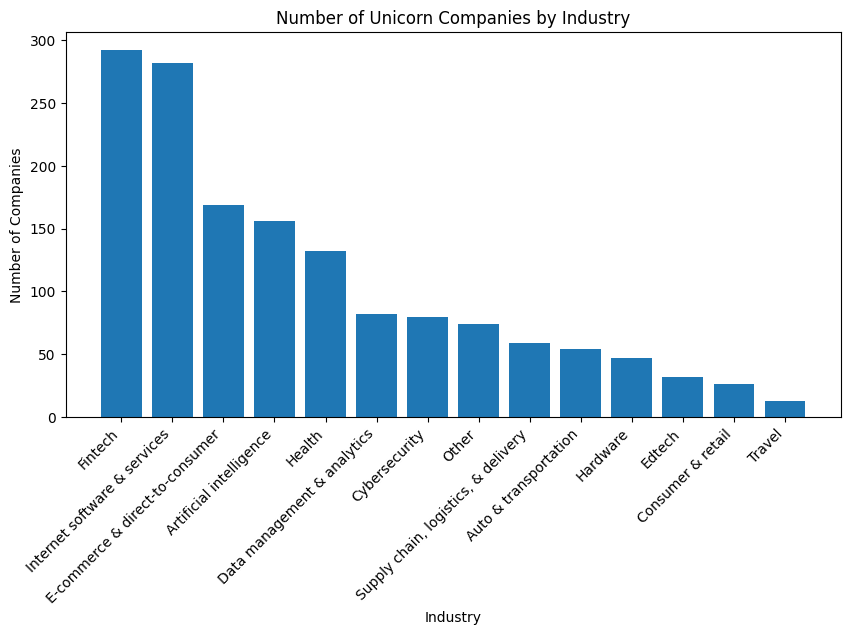

In [34]:
#2. Number of Unicorn Companies by Industry
industry_counts = (
    df_analysis["Industry"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
plt.bar(industry_counts.index, industry_counts.values)
plt.title("Number of Unicorn Companies by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Companies")
plt.xticks(rotation=45, ha="right")
plt.show()

- Fintech accounts for the highest number of unicorn companies, followed by software services and E-commerce..

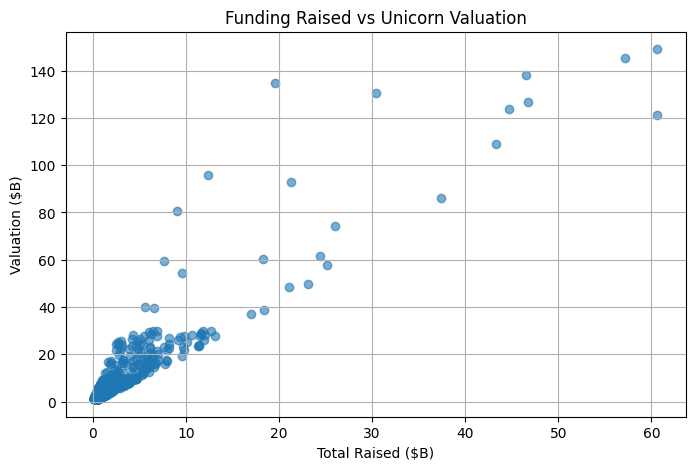

In [35]:
#Funding Raised vs Unicorn Valuation
plt.figure(figsize=(8,5))
plt.scatter(
    df_analysis["Total Raised ($B)"],
    df_analysis["Valuation ($B)"],
    alpha=0.6
)

plt.title("Funding Raised vs Unicorn Valuation")
plt.xlabel("Total Raised ($B)")
plt.ylabel("Valuation ($B)")
plt.grid(True)
plt.show()


- This relationship suggests that companies attracting larger investments are often associated with higher valuations

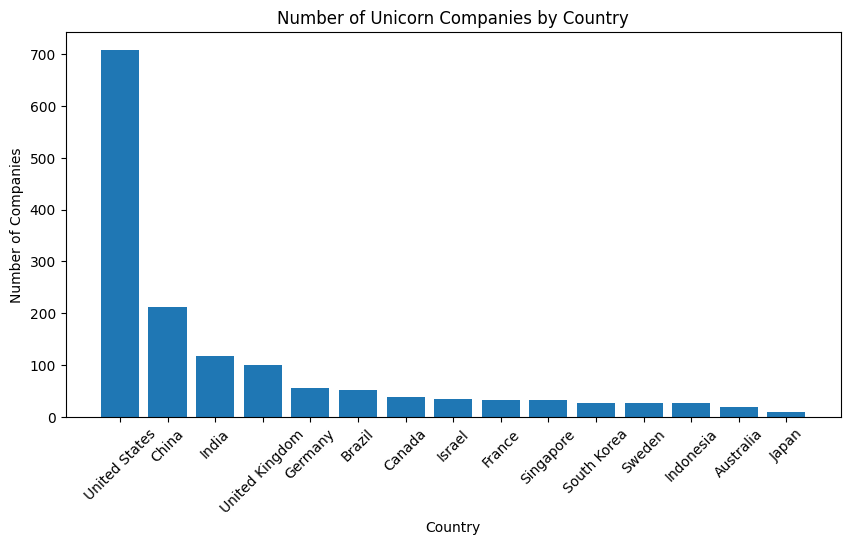

In [36]:
# Number of Unicorn Companies by Country
country_counts = (
    df_analysis["Country"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
plt.bar(country_counts.index, country_counts.values)
plt.title("Number of Unicorn Companies by Country")
plt.xlabel("Country")
plt.ylabel("Number of Companies")
plt.xticks(rotation=45)
plt.show()

- The United States has the highest number of unicorn companies, followed by China and India.

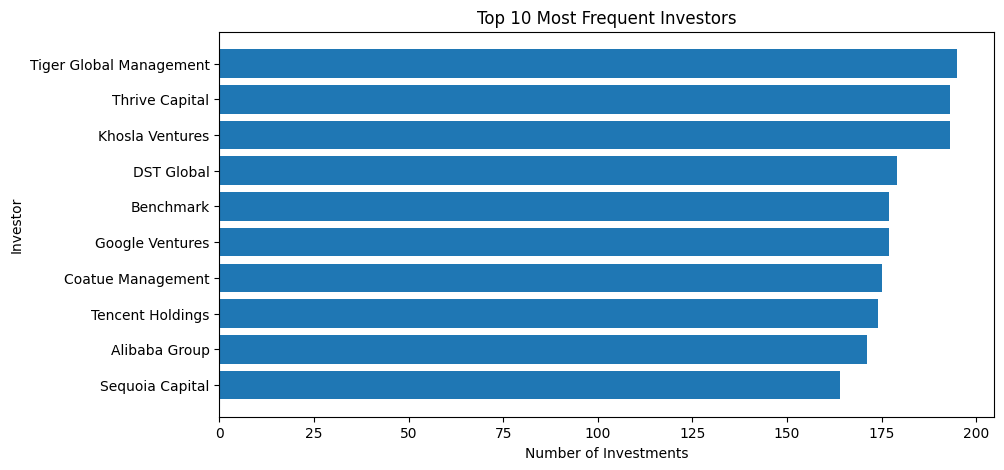

In [37]:
# top 10 investor
top10 = investor_freq.head(10)

plt.figure(figsize=(10,5))
plt.barh(top10.index, top10["Frequency"])
plt.title("Top 10 Most Frequent Investors")
plt.xlabel("Number of Investments")
plt.ylabel("Investor")
plt.gca().invert_yaxis()
plt.show()

- Tiger Global Management is the most frequent investor, followed closely by Thrive Capital and Khosla Ventures, and so on..

### Part 6 – Key Insights


1. Most unicorn companies have valuations close to US$1 billion, while only a small number achieve exceptionally high valuations, indicating that extremely valuable unicorns are relatively rare.

2. Companies that raise larger amounts of funding generally tend to have higher valuations, suggesting that investor confidence and capital availability are associated with company growth.

3. The Fintech industry contains the largest number of unicorn companies, showing that financial technology remains one of the strongest sectors for high-growth startups.

4. The United States dominates the global unicorn ecosystem, with considerably more unicorn companies than any other country, highlighting its strong startup and investment environment.

5. Tiger Global Management appears most frequently as an investor in unicorn companies, indicating its significant role in funding successful startups.

6. The strongest relationship in the dataset is between total funding raised and company valuation, while other numerical variables show relatively weak correlations.

7. Average valuations differ noticeably across industries, suggesting that some sectors generate higher company values than others rather than all industries growing at the same rate.

8. The dataset contains no missing values or duplicate records, indicating high data quality and allowing the analysis to be performed without major data cleaning.

9. Although valuation contains many statistical outliers, these companies represent genuine high-value businesses rather than data errors, so retaining them provides a more realistic view of the unicorn market.

10. Logical validation identified two inconsistent records where companies appeared to become unicorns before they were founded. Removing these records improved the reliability and accuracy of the analysis.


### Part 7 – Business Recommendations

1. **Focus investment efforts on high-growth industries such as Fintech.**  
   Since Fintech contains the largest number of unicorn companies, investors and venture capital firms should prioritize opportunities in this sector while continuing to monitor emerging industries.

2. **Use funding as an indicator of company growth potential.**  
   The positive relationship between total funding raised and company valuation suggests that funding trends can help identify startups with strong growth prospects.

3. **Improve data collection by separating investor names into individual records.**  
   The "Select Investors" column stores multiple investors in a single cell, making investor analysis more difficult. Splitting these into separate records would enable more accurate analysis of investment networks and partnerships.

4. **Implement automated data validation rules.**  
   Validation checks should ensure that a company's unicorn joining year cannot occur before its founding year, preventing logically inconsistent records from entering the dataset.

5. **Retain legitimate outliers during business analysis.**  
   Extremely high valuations and funding amounts represent real unicorn companies rather than errors. These observations should be preserved because they provide valuable insights into exceptional business success.

---

### Part 8 – Reflection

### What was the most challenging data quality problem?
The most challenging data quality problem was discovering logical inconsistencies through data visualization. While exploring the charts, I noticed that two companies appeared to have become unicorns before they were founded. This observation led me to investigate the records further and confirm that the data contained impossible dates that needed to be corrected.

### Which decision required the most critical thinking?
The decision that required the most critical thinking was how to analyse the **Select Investors** column. Since each record contained a list of investors instead of a single value, I needed to transform the data by separating the investor names before performing frequency analysis. This ensured that each investor was counted accurately.

### What was the most interesting finding?
The most interesting finding was that the number of investors had almost no correlation with company valuation. This suggests that having more investors does not necessarily result in a higher company valuation. Instead, factors such as the amount of funding raised, business performance, or investor quality may have a greater influence on a unicorn company's value.

### If you repeated this project, what would you do differently?
I would perform feature engineering, such as calculating company age and the number of years required to become a unicorn.

### What did you learn about EDA from this project?
This project taught me that EDA is more than summarizing data and creating charts. It involves checking whether the data is logically valid, identifying inconsistencies such as impossible dates, transforming complex columns into analyzable formats, and validating data quality before drawing conclusions from the analysis.

## 2. Clustering


In [38]:
# clustering by K mean
# data
df_analysis.head()


,Company,Valuation ($B),Date Joined,Country,City,Industry,Select Investors,Founded Year,Total Raised ($B),Financial Stage,Investors Count,Joined Year
0,Grid Group94,1.58,2026-12-04,United States,Los Angeles,Data management & analytics,"DST Global, Kleiner Perkins Caufield & Byers, ...",2016,0.305,Series E,5,2026
1,Meta Labs,2.55,2026-11-26,Germany,Munich,Fintech,Y Combinator,2022,0.528,Series D,12,2026
2,Link Group,2.32,2026-10-14,Israel,Tel Aviv,Health,"New Enterprise Associates, DST Global, Alibaba...",2015,0.940,Series C,16,2026
3,Aeroify68,4.26,2026-10-14,United States,New York,Fintech,"DST Global, Thrive Capital",2022,1.938,Series C,2,2026
4,Finly38,7.38,2026-09-26,United States,Los Angeles,Other,"SoftBank Group, Sequoia Capital",2020,1.242,Series F,11,2026


In [41]:
# one hot encoding to features + scaling + the imvestros is a series her and i took it to its own df

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans



#  Features prep


X = df_analysis[
    ['Country', 'Industry', 'Financial Stage',
     'Valuation ($B)', 'Total Raised ($B)', 'Investors Count']
]


# Investors separately


investors_df = df_analysis['Select Investors'].str.split(', ', expand=True)


# One-hot encode categorical features


X_encoded = pd.get_dummies(
    X,
    columns=['Country', 'Industry', 'Financial Stage']
)


# Scale numerical features


scaler = StandardScaler()

numeric_cols = [
    'Valuation ($B)',
    'Total Raised ($B)',
    'Investors Count'
]

X_encoded[numeric_cols] = scaler.fit_transform(
    X_encoded[numeric_cols]
)



# Multi-hot encode investors

# One column per unique investor,
# regardless of which position they appeared in.

investors_encoded = pd.get_dummies(
    investors_df.stack()
).groupby(level=0).max()

# Make sure the rows match df_analysis
investors_encoded = investors_encoded.reindex(
    df_analysis.index,
    fill_value=False
)



#  Combine all features back


X_final = pd.concat(
    [X_encoded, investors_encoded],
    axis=1
)

print("Final feature shape:", X_final.shape)

Final feature shape: (1498, 62)


In [42]:
# visualize to decide company by industray  PCA to over view all prattrens


pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_final)

print("Explained variance ratio:",
      pca.explained_variance_ratio_)

print("Total variance explained:",
      pca.explained_variance_ratio_.sum())


Explained variance ratio: [0.25180204 0.13092002]
Total variance explained: 0.3827220612216605


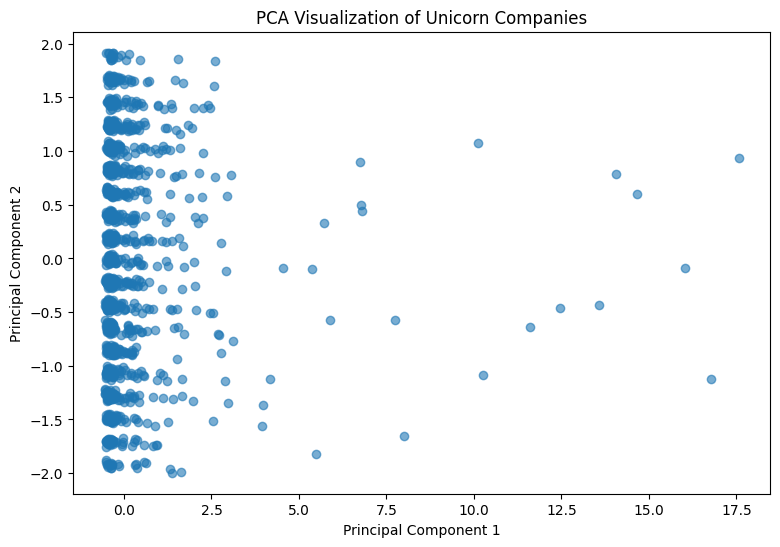

In [43]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.6
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of Unicorn Companies')

plt.show()

### It seemes like theres around 3-4 clusters 
- on the left there 2 kinda overlapping
- on the right and middle they seem scattered

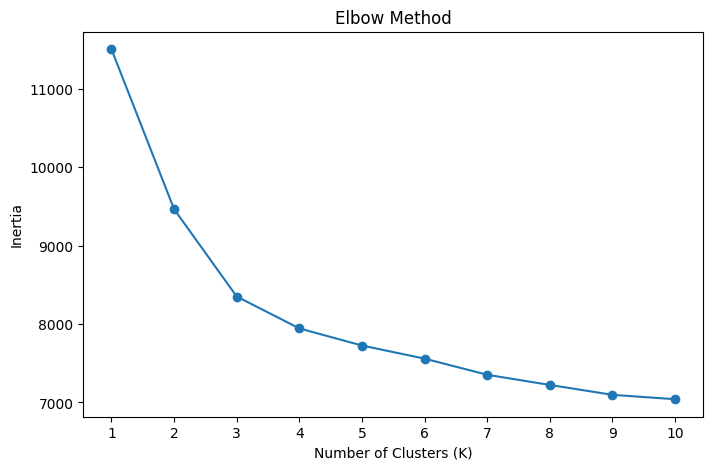

In [45]:
# Elbow method 
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_final)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.xticks(range(1, 11))
plt.show()

### after 4 clusters seems like the curve becomes flatter so id set 4 clusters

In [ ]:
# K mean 
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_final)
# getting labels of cluster
df_analysis['KMeans_Cluster'] = kmeans_labels


Explained variance: [0.25180204 0.13092002]
Total explained variance: 0.3827220612216605


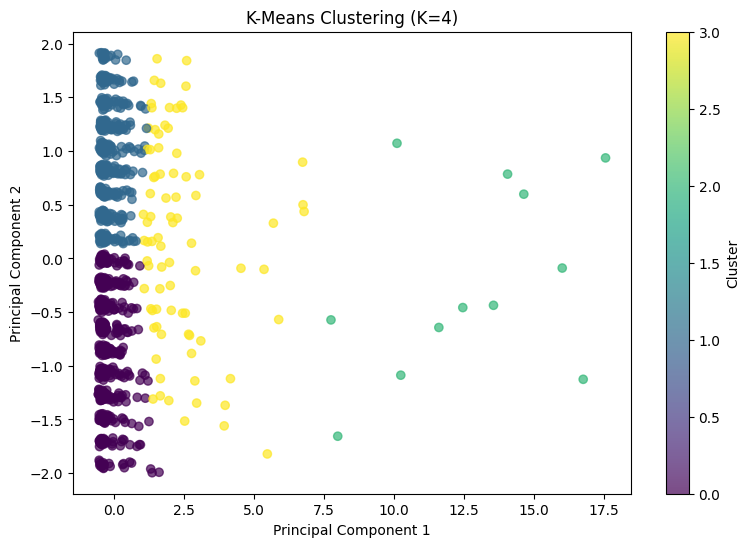

In [48]:
# Visualize result
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_final)

print("Explained variance:",
      pca.explained_variance_ratio_)

print("Total explained variance:",
      pca.explained_variance_ratio_.sum())


plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    alpha=0.7
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering (K=4)')
plt.colorbar(label='Cluster')

plt.show()

In [ ]:
# Eval

In [49]:
# Density
pca_dbscan = PCA(n_components=0.95)

X_pca_dbscan = pca_dbscan.fit_transform(X_final)

print("Original features:", X_final.shape[1])
print("PCA features:", X_pca_dbscan.shape[1])

Original features: 62
PCA features: 43


In [50]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_pca_dbscan)

df_analysis['DBSCAN_Cluster'] = dbscan_labels

In [51]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_pca_dbscan)

df_analysis['DBSCAN_Cluster'] = dbscan_labels

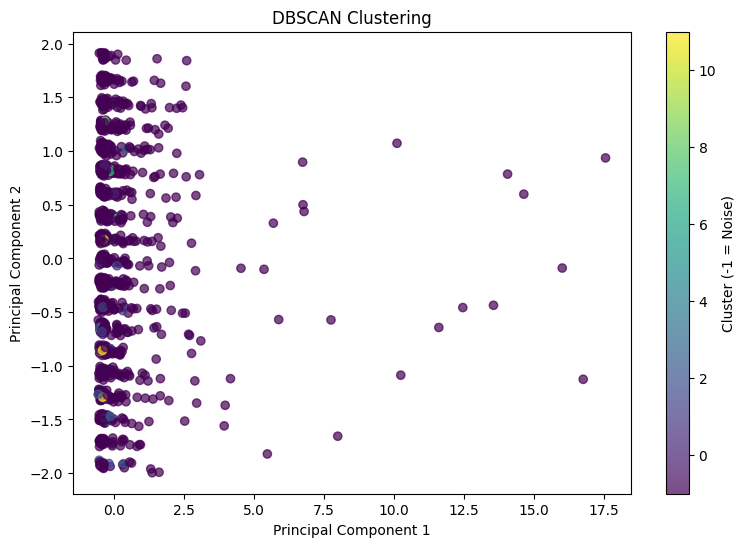

In [52]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    alpha=0.7
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Clustering')
plt.colorbar(label='Cluster (-1 = Noise)')

plt.show()

In [53]:
# Eval 
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

kmeans_silhouette = silhouette_score(
    X_final,
    kmeans_labels
)

kmeans_db = davies_bouldin_score(
    X_final,
    kmeans_labels
)

kmeans_ch = calinski_harabasz_score(
    X_final,
    kmeans_labels
)

print("K-Means Evaluation")
print("------------------")
print("Silhouette Score:", kmeans_silhouette)
print("Davies-Bouldin Index:", kmeans_db)
print("Calinski-Harabasz Score:", kmeans_ch)

K-Means Evaluation
------------------
Silhouette Score: 0.11679982110184295
Davies-Bouldin Index: 1.9040798531667407
Calinski-Harabasz Score: 223.33915037672492


In [54]:
# eval d scan
import numpy as np

mask = dbscan_labels != -1

dbscan_clusters = dbscan_labels[mask]
dbscan_data = X_pca_dbscan[mask]

if len(set(dbscan_clusters)) >= 2:

    dbscan_silhouette = silhouette_score(
        dbscan_data,
        dbscan_clusters
    )

    dbscan_db = davies_bouldin_score(
        dbscan_data,
        dbscan_clusters
    )

    dbscan_ch = calinski_harabasz_score(
        dbscan_data,
        dbscan_clusters
    )

    print("DBSCAN Evaluation")
    print("-----------------")
    print("Silhouette Score:", dbscan_silhouette)
    print("Davies-Bouldin Index:", dbscan_db)
    print("Calinski-Harabasz Score:", dbscan_ch)

else:
    print("DBSCAN did not find enough clusters to evaluate.")

DBSCAN Evaluation
-----------------
Silhouette Score: 0.09963316597984936
Davies-Bouldin Index: 1.539379222089117
Calinski-Harabasz Score: 8.305587749589474


In [55]:
n_clusters = len(set(dbscan_labels)) - (
    1 if -1 in dbscan_labels else 0
)

n_noise = np.sum(dbscan_labels == -1)

print("Number of DBSCAN clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of DBSCAN clusters: 12
Number of noise points: 1382


In [56]:
comparison = pd.DataFrame({
    'Model': ['K-Means', 'DBSCAN'],
    'Silhouette': [
        kmeans_silhouette,
        dbscan_silhouette
    ],
    'Davies-Bouldin': [
        kmeans_db,
        dbscan_db
    ],
    'Calinski-Harabasz': [
        kmeans_ch,
        dbscan_ch
    ]
})

comparison

,Model,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,0.116800,1.904080,223.339150
1,DBSCAN,0.099633,1.539379,8.305588


- K-Means performed slightly better overall for this dataset. It achieved a higher Silhouette Score and a much higher Calinski-Harabasz Score, indicating better overall cluster separation. DBSCAN achieved a lower Davies-Bouldin Index, suggesting more compact clusters, but its very low Calinski-Harabasz score and lower Silhouette Score indicate that the density-based grouping was not as strong overall.

- Neither method produced highly distinct clusters, since the Silhouette Scores are close to zero.

In [57]:
# analyze each group manyally from k mean and denceity 
print(df_analysis['KMeans_Cluster'].value_counts().sort_index())

KMeans_Cluster
0    740
1    664
2     12
3     82
Name: count, dtype: int64


In [58]:
cluster_summary = df_analysis.groupby('KMeans_Cluster')[
    ['Valuation ($B)', 'Total Raised ($B)', 'Investors Count']
].agg(['mean', 'median'])

cluster_summary

Valuation ($B)          Total Raised ($B)           \
                         mean   median              mean   median   
KMeans_Cluster                                                      
0                    3.401338    2.300          0.990389   0.6535   
1                    3.338163    2.265          0.963294   0.6685   
2                  119.333333  125.245         41.190500  43.9995   
3                   28.287439   24.375          8.461671   6.8715   

               Investors Count         
                          mean median  
KMeans_Cluster                         
0                     6.135135    6.0  
1                    14.445783   14.0  
2                    10.083333    9.0  
3                    11.109756   11.0

### it seemes like pattren over valution and fund raised so separating the companies according to their financial scale

In [60]:
# to analyze more pattrens id check catgory freqency in each catgory
industry_distribution = pd.crosstab(
    df_analysis['KMeans_Cluster'],
    df_analysis['Industry'],
    normalize='index'
) * 100

industry_distribution.round(2)
    

Industry,Artificial intelligence,Auto & transportation,Consumer & retail,Cybersecurity,Data management & analytics,E-commerce & direct-to-consumer,Edtech,Fintech,Hardware,Health,Internet software & services,Other,"Supply chain, logistics, & delivery",Travel
KMeans_Cluster,,,,,,,,,,,,,,
0,10.68,3.51,1.76,5.14,5.54,11.35,2.30,19.59,2.84,8.65,18.51,5.14,3.92,1.08
1,10.84,4.07,1.81,5.27,5.42,10.69,1.81,19.43,3.31,8.28,19.58,4.97,3.77,0.75
2,8.33,0.00,0.00,8.33,8.33,16.67,0.00,16.67,0.00,0.00,25.00,0.00,16.67,0.00
3,4.88,1.22,1.22,7.32,4.88,14.63,3.66,19.51,4.88,15.85,14.63,3.66,3.66,0.00


In [61]:
country_distribution = pd.crosstab(
    df_analysis['KMeans_Cluster'],
    df_analysis['Country'],
    normalize='index'
) * 100

financial_stage_distribution = pd.crosstab(
    df_analysis['KMeans_Cluster'],
    df_analysis['Financial Stage'],
    normalize='index'
) * 100

In [62]:
country_distribution

Country,Australia,Brazil,Canada,China,France,Germany,India,Indonesia,Israel,Japan,Singapore,South Korea,Sweden,United Kingdom,United States
KMeans_Cluster,,,,,,,,,,,,,,,
0,0.810811,4.594595,2.972973,14.054054,1.891892,3.648649,6.621622,1.756757,1.756757,0.270270,2.432432,2.297297,1.081081,6.756757,49.054054
1,1.807229,2.259036,1.957831,14.759036,2.409639,4.216867,9.186747,1.807229,3.162651,1.054217,1.506024,1.355422,2.710843,6.475904,45.331325
2,0.000000,0.000000,8.333333,0.000000,0.000000,0.000000,8.333333,8.333333,0.000000,0.000000,0.000000,0.000000,8.333333,0.000000,66.666667
3,1.219512,4.878049,3.658537,13.414634,3.658537,2.439024,8.536585,1.219512,0.000000,1.219512,4.878049,2.439024,1.219512,8.536585,42.682927


In [63]:
financial_stage_distribution

Financial Stage,Pre-IPO,Private Equity,Series B,Series C,Series D,Series E,Series F
KMeans_Cluster,,,,,,,
0,10.945946,5.000000,4.594595,19.459459,31.351351,19.864865,8.783784
1,7.831325,4.969880,4.819277,21.686747,31.927711,19.427711,9.337349
2,8.333333,8.333333,8.333333,25.000000,8.333333,25.000000,16.666667
3,6.097561,6.097561,6.097561,23.170732,25.609756,18.292683,14.634146


In [66]:
for cluster in sorted(df_analysis['KMeans_Cluster'].unique()):

    mask = df_analysis['KMeans_Cluster'] == cluster

    frequencies = (
        investors_df[mask]
        .stack()
        .value_counts()
        / mask.sum()
        * 100
    )

    print(f"\n===== Cluster {cluster} =====")
    print(frequencies.head(10).round(2))


===== Cluster 0 =====
Tiger Global Management    12.57
Thrive Capital             12.43
Google Ventures            12.30
Khosla Ventures            11.76
Coatue Management          11.35
SoftBank Group             11.35
DST Global                 11.22
Y Combinator               10.81
Benchmark                  10.81
Andreessen Horowitz        10.68
Name: count, dtype: float64

===== Cluster 1 =====
Khosla Ventures              14.16
Tiger Global Management      13.70
Thrive Capital               13.25
DST Global                   13.25
Benchmark                    12.95
Tencent Holdings             12.80
Alibaba Group                12.50
Accel                        12.05
Coatue Management            11.60
Bessemer Venture Partners    11.45
Name: count, dtype: float64

===== Cluster 2 =====
Bessemer Venture Partners    25.00
Index Ventures               25.00
Sequoia Capital              25.00
Founders Fund                16.67
Coatue Management            16.67
Y Combinator        

### some interputation on the cluster based on statisitcal + frequency inturuptation
- Cluster 2: extreme/highest-value companies
- Cluster 3: high-value companies
- Clusters 0 & 1: lower-value companies

#### Industry doesn't strongly define the clusters

#### the United States dominates every cluster

#### K-Means primarily separates companies by financial scale, especially valuation and total funding, while Investors Count creates a strong secondary distinction between the two large low-scale clusters.

#### The clustering is not strongly separating companies by specific investor identity.



### investros in each cluster 
in cluster 3 high valued compaines investros are:
- Bessemer → 25%
- Index Ventures → 25%
- Sequoia → 25%
- Founders Fund → 16.67%
- Coatue → 16.67%
- Y Combinator → 16.67%


- This suggests these investors are present relatively frequently among the extreme-value companies, showing invesemnt quality fromthese investros as theyre investing in extrem valued compines

### in summary
K-Means identified four main company profiles. The strongest separation is based on financial scale, with Clusters 2 and 3 representing high- and extreme-valuation companies, while Clusters 0 and 1 contain the majority of companies at a lower financial scale. Among the two large lower-scale clusters, investor count is the main distinction: Cluster 1 has more than twice the average number of investors as Cluster 0 despite having almost identical valuation and funding levels.

Industry, country, and financial stage distributions are relatively similar across the major clusters, suggesting they are not the primary drivers of the segmentation. Specific investor names also overlap substantially, although some investors appear more frequently within the high-value clusters.
- Note: "K-Means produced four segments, but the low Silhouette Score (0.117) indicates substantial overlap between the clusters. DBSCAN showed a similarly low Silhouette Score (0.100), suggesting that the underlying data does not contain strongly separated density-based groups."